# Undersampling for speed

We have established that resampling does not improve a well-tuned model (resampling, class weights and threshold adjustment are equivalent; see Elkan). The question here is different: on a large, severely imbalanced dataset, can we **undersample the majority to train faster** without losing performance, and keep the probabilities calibrated by putting the original class prior back with weights?

Four datasets span the imbalance/size spectrum (**creditcard** ~0.17%/199k, **protein_homo** ~0.9%/102k, **diabetes130** ~11%/71k, **isolet** ~7.7%/5.5k), and two base learners are compared: a parallel **Random Forest** and a sequential **Gradient Boosting** classifier, to see whether the speed payoff depends on how the model's cost scales with data size. Metrics are threshold-free (ROC-AUC, average precision, Brier, mean predicted probability). Random Forest runs the full learning curve over 5 seeds; Gradient Boosting runs the full-data reference plus the undersampling curve over 3 seeds. Prior restoration uses `sample_weight` (Gradient Boosting has no `class_weight`).

In [1]:
import pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
os.makedirs('../figures', exist_ok=True)

DATASETS = ['creditcard', 'protein_homo', 'diabetes130', 'isolet']
LEARNERS = ['rf', 'gbm']
res = {}
for d in DATASETS:
    res[d] = {}
    for l in LEARNERS:
        p = f'../models/undersampling-speed/{d}_{l}_results.pkl'
        if os.path.exists(p):
            with open(p, 'rb') as f:
                res[d][l] = pickle.load(f)
DATASETS = [d for d in DATASETS if 'rf' in res.get(d, {})]

def agg(records, by):
    df = pd.DataFrame(records)
    g = df.groupby(by)
    return g.mean(numeric_only=True), g.std(numeric_only=True)

def full_ref(d, l):
    m, _ = agg(res[d][l]['A_learning_curve'], 'fraction')
    return m.loc[1.0]

def prior_curve(d, l):
    m, s = agg(res[d][l]['B_undersample'], ['neg_per_pos', 'weights'])
    return m.xs('prior', level='weights'), s.xs('prior', level='weights')

LCOL = {'rf': 'tab:blue', 'gbm': 'tab:orange'}
{d: list(res[d]) for d in DATASETS}

{'creditcard': ['rf', 'gbm'],
 'protein_homo': ['rf', 'gbm'],
 'diabetes130': ['rf', 'gbm'],
 'isolet': ['rf', 'gbm']}

## Summary: speed/performance tradeoff per learner

For each dataset and learner: the full-data model, and the fastest prior-weighted undersampling whose average precision stays within 0.01 of the full model (the speed 'knee'). `speedup` is the ratio of fit times; `saved_s` is wall-clock seconds saved.

In [2]:
rows = []
for d in DATASETS:
    for l in LEARNERS:
        if l not in res[d]:
            continue
        ref = full_ref(d, l)
        mp, _ = prior_curve(d, l)
        ok = mp[mp['ap'] >= ref['ap'] - 0.01]
        pick = ok['fit_time_s'].idxmin() if len(ok) else mp['ap'].idxmax()
        knee = mp.loc[pick]
        meta = res[d][l]['meta']
        rows.append({
            'dataset': d, 'learner': l,
            'pos_%': round(100 * meta['n_pos_full'] / (meta['n_pos_full'] + meta['n_neg_full']), 2),
            'full_fit_s': round(ref['fit_time_s'], 1),
            'full_ap': round(ref['ap'], 3),
            'knee_ratio': int(pick),
            'knee_ap': round(knee['ap'], 3),
            'speedup': round(ref['fit_time_s'] / knee['fit_time_s'], 1),
            'saved_s': round(ref['fit_time_s'] - knee['fit_time_s'], 1),
            'mean_p_prior': round(knee['mean_prob'], 4),
            'true_prior': round(meta['test_prior'], 4),
        })
summary = pd.DataFrame(rows).set_index(['dataset', 'learner'])
summary

pos_%  full_fit_s  full_ap  knee_ratio  knee_ap  \
dataset      learner                                                    
creditcard   rf        0.17        35.5    0.833         200    0.814   
             gbm       0.17       122.6    0.643         200    0.642   
protein_homo rf        0.89        17.7    0.860          50    0.852   
             gbm       0.89        95.1    0.802         100    0.796   
diabetes130  rf       11.14         2.0    0.204           1    0.198   
             gbm      11.14         7.3    0.217           2    0.210   
isolet       rf        7.70         0.7    0.934          10    0.929   
             gbm       7.70        42.0    0.908          10    0.901   

                      speedup  saved_s  mean_p_prior  true_prior  
dataset      learner                                              
creditcard   rf           4.4     27.4        0.0019      0.0017  
             gbm          3.3     85.3        0.0019      0.0017  
protein_homo rf           2.4     10.3        0.0103      0.0089  
             gbm          1.1     11.8        0.0088      0.0089  
diabetes130  rf           5.2      1.6        0.2041      0.1121  
             gbm          2.9      4.8        0.1141      0.1121  
isolet       rf           1.1      0.1        0.0844      0.0769  
             gbm          1.2      7.3        0.0723      0.0769

## Part A: how much data do we actually need? (Random Forest)

Growing stratified subsamples at the original prior. ROC-AUC flattens early; average precision keeps climbing because it is gated by the number of positives, which only grows with total size.

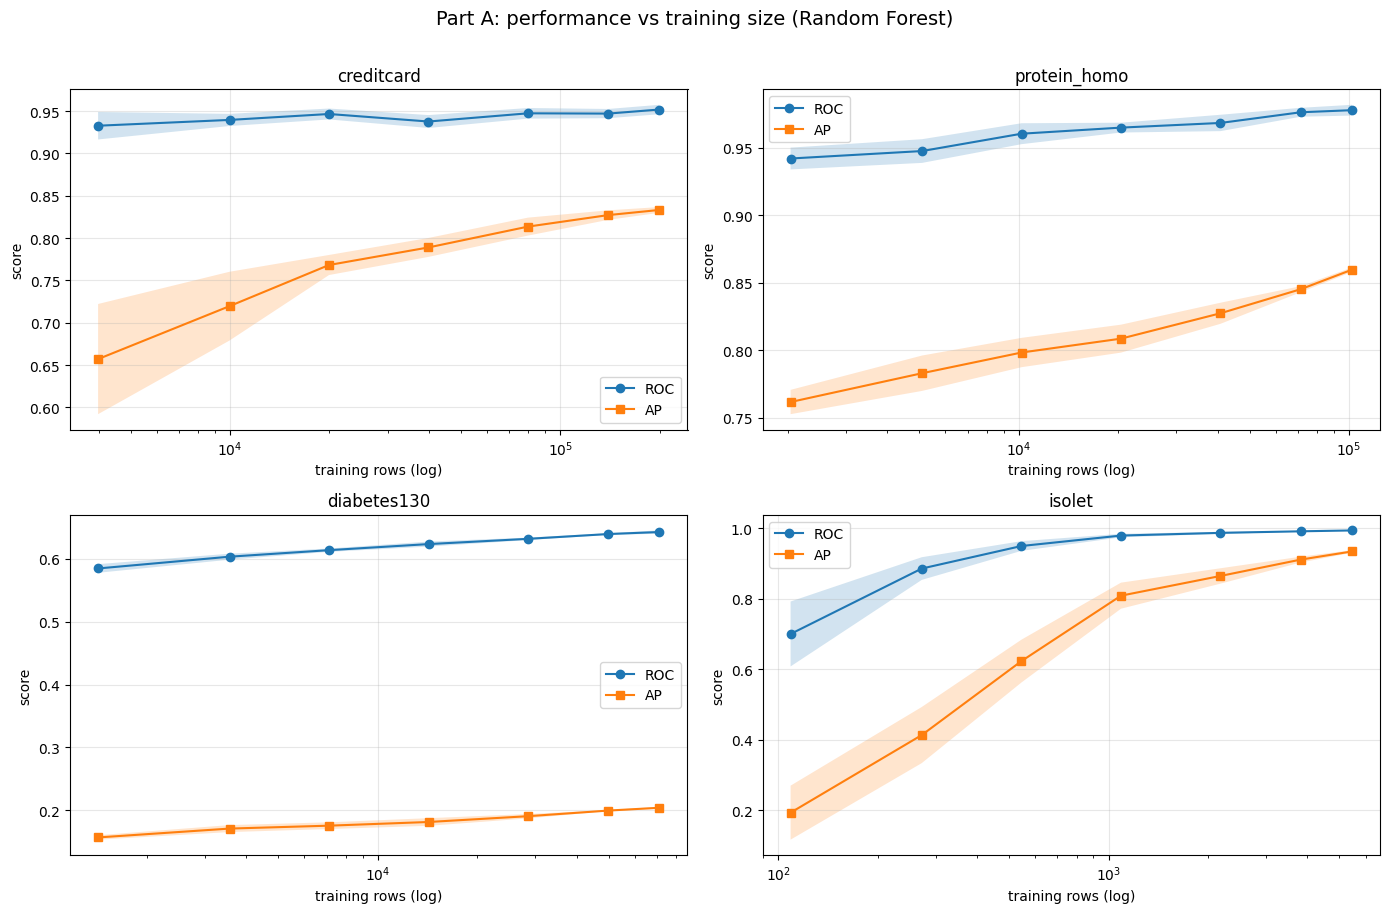

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, d in zip(axes.ravel(), DATASETS):
    m, s = agg(res[d]['rf']['A_learning_curve'], 'fraction')
    for col, mk in [('roc', 'o'), ('ap', 's')]:
        ax.plot(m.n_train, m[col], mk + '-', label=col.upper())
        ax.fill_between(m.n_train, m[col] - s[col], m[col] + s[col], alpha=0.2)
    ax.set_xscale('log'); ax.set_xlabel('training rows (log)'); ax.set_ylabel('score')
    ax.set_title(d); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Part A: performance vs training size (Random Forest)', y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig('../figures/speed_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Part B: performance retention, RF vs GBM

Prior-weighted average precision vs undersampling ratio, against each learner's full-data reference (dashed). On the severely imbalanced sets it holds up over a wide range; GBM is a little more data-hungry to keep AP.

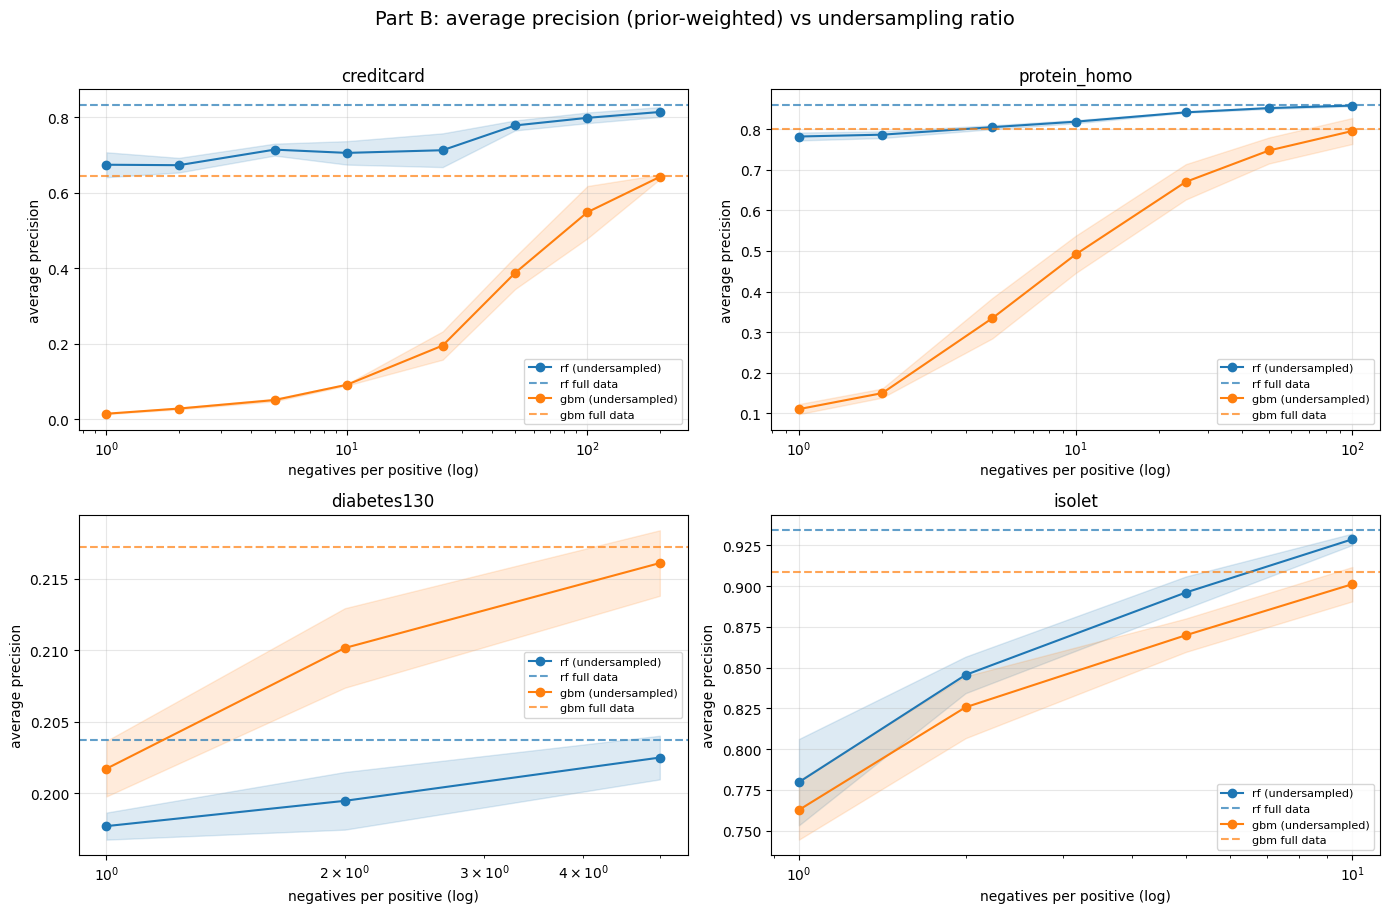

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, d in zip(axes.ravel(), DATASETS):
    for l in LEARNERS:
        if l not in res[d]:
            continue
        mp, sp = prior_curve(d, l)
        ax.plot(mp.index, mp['ap'], 'o-', color=LCOL[l], label=f'{l} (undersampled)')
        ax.fill_between(mp.index, mp['ap'] - sp['ap'], mp['ap'] + sp['ap'], color=LCOL[l], alpha=0.15)
        ax.axhline(full_ref(d, l)['ap'], ls='--', color=LCOL[l], alpha=0.7, label=f'{l} full data')
    ax.set_xscale('log'); ax.set_xlabel('negatives per positive (log)')
    ax.set_ylabel('average precision'); ax.set_title(d); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Part B: average precision (prior-weighted) vs undersampling ratio', y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig('../figures/speed_perf.png', dpi=150, bbox_inches='tight')
plt.show()

## Training cost and speedup, RF vs GBM

Fit time vs undersampling ratio (log-log), with each learner's full-data fit marked. GBM's full fits are several times slower, so undersampling saves more wall-clock for GBM in absolute terms, even though its speedup *ratio* is smaller (RF's deep trees scale worse with n, so dropping rows shrinks RF's cost faster).

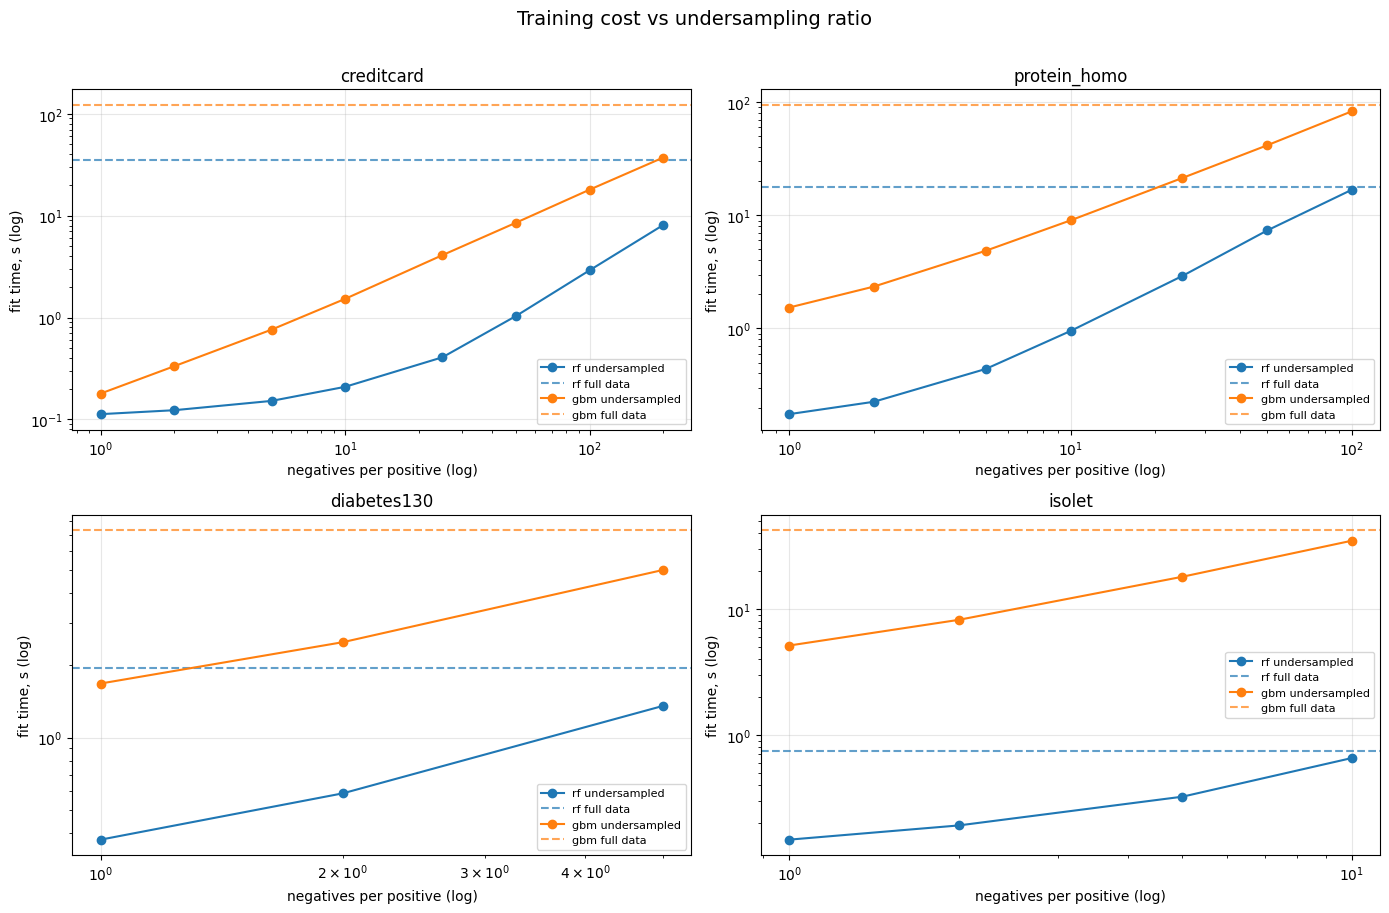

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, d in zip(axes.ravel(), DATASETS):
    for l in LEARNERS:
        if l not in res[d]:
            continue
        mp, _ = prior_curve(d, l)
        ax.plot(mp.index, mp['fit_time_s'], 'o-', color=LCOL[l], label=f'{l} undersampled')
        ax.axhline(full_ref(d, l)['fit_time_s'], ls='--', color=LCOL[l], alpha=0.7, label=f'{l} full data')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('negatives per positive (log)'); ax.set_ylabel('fit time, s (log)')
    ax.set_title(d); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Training cost vs undersampling ratio', y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig('../figures/speed_cost.png', dpi=150, bbox_inches='tight')
plt.show()

## Calibration, RF vs GBM

Mean predicted probability vs undersampling ratio: dashed = no weights, solid = prior weights, dotted black = true prior. Undersampling makes the unweighted model overpredict; the prior weights pull it back. The effect is largest where the undersampling is aggressive relative to the dataset's own ratio.

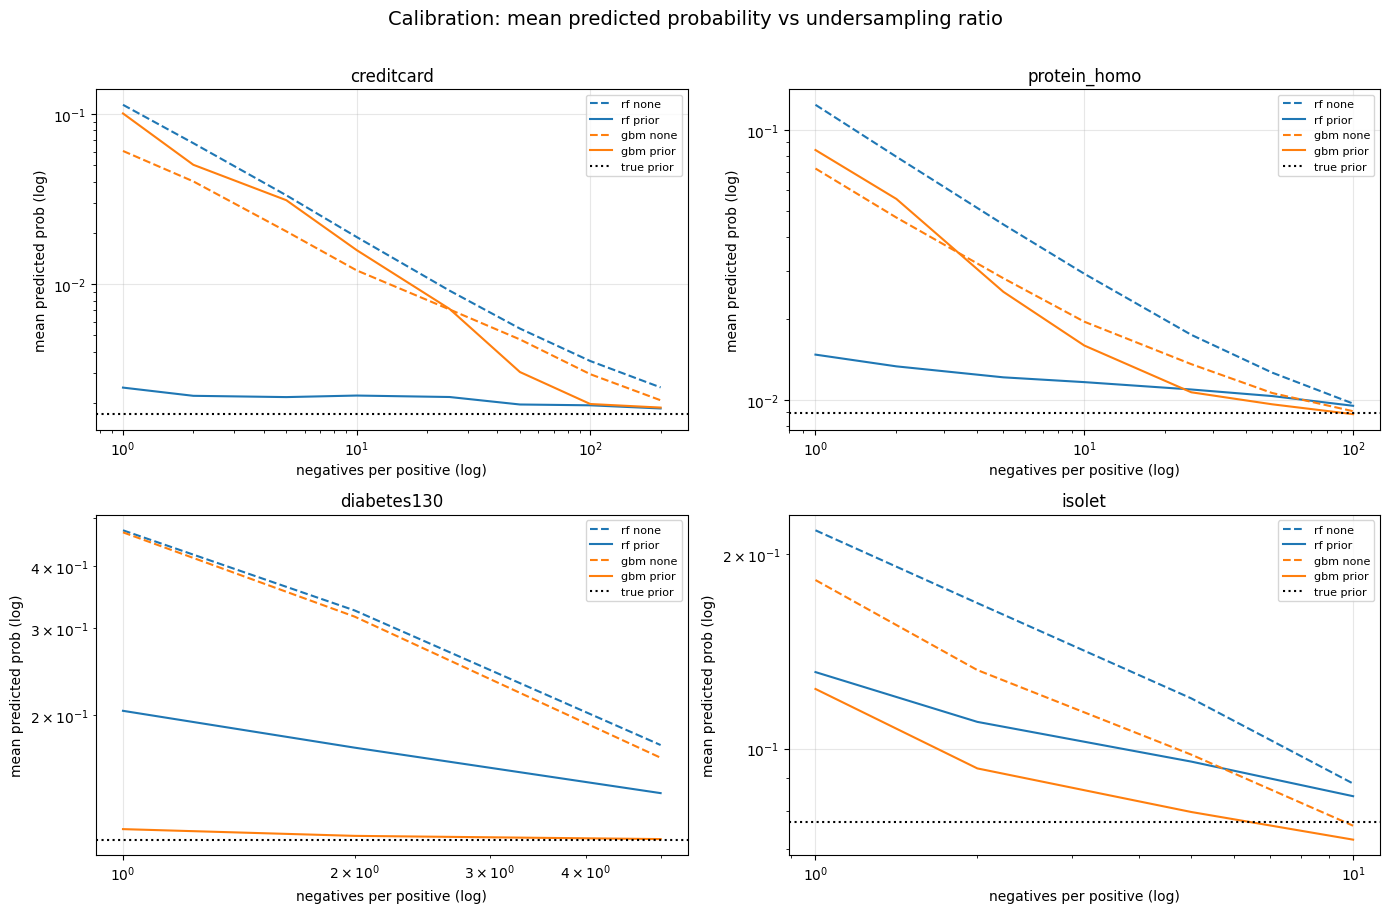

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, d in zip(axes.ravel(), DATASETS):
    for l in LEARNERS:
        if l not in res[d]:
            continue
        m, _ = agg(res[d][l]['B_undersample'], ['neg_per_pos', 'weights'])
        for w, ls in [('none', '--'), ('prior', '-')]:
            mw = m.xs(w, level='weights')
            ax.plot(mw.index, mw['mean_prob'], ls, color=LCOL[l], label=f'{l} {w}')
    ax.axhline(res[d]['rf']['meta']['test_prior'], ls=':', color='k', label='true prior')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('negatives per positive (log)'); ax.set_ylabel('mean predicted prob (log)')
    ax.set_title(d); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Calibration: mean predicted probability vs undersampling ratio', y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig('../figures/speed_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## Takeaways

1. **Undersampling for speed works on big imbalanced data, but it is a tradeoff and it is learner-dependent.** For both learners, prior-weighted undersampling holds ROC at the full-data level and keeps average precision within ~0.01-0.02 on creditcard and protein_homo while using a fraction of the rows. On diabetes130 and isolet the full fit is already cheap, so there is no speed case.
2. **A costlier learner saves more wall-clock, but not a bigger multiple.** GBM's full-data fits are 3-4x slower than RF's (creditcard ~123s vs ~36s). Undersampling to the AP-preserving point saves more *absolute* time for GBM (creditcard ~85s vs ~27s) but at a similar-or-smaller *ratio* (3.3x vs 4.4x). RF's deep unbounded trees scale super-linearly with n, so dropping rows shrinks its cost faster; GBM's shallow boosted trees scale ~linearly and it needs a little more data to hold AP. So 'the speedup multiplies more for slower models' is false; 'you save more seconds' is true.
3. **The prior-weight calibration fix generalizes across learners.** Implemented as `sample_weight` (GBM has no `class_weight`), it restores the mean predicted probability to the true prior wherever undersampling distorts it (diabetes130: GBM overpredicts at ~0.32, restored to ~0.114 vs a true 0.112), and does no harm where the undersampling is mild enough that the model is already calibrated.
4. **ROC-AUC and average precision still disagree under balancing** for both learners; the metric choice matters as much as the method.

*Random Forest: 5 seeds, full learning curve. Gradient Boosting: 3 seeds, full-data reference plus the undersampling curve. Bands are ±1 std.*